In [3]:
from uszipcode import SearchEngine
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
from scipy.stats import mstats, pearsonr
import sqlite3
from fuzzywuzzy import fuzz

warnings.filterwarnings('ignore')

In [4]:
manufacturer_corrections = {'gmc': 'GMC', 'Gmc':'GMC', 'GMC/CHEVY':'GMC', 'nissan': 'Nissan', 'NISSAN': 'Nissan', 'Murano': 'Nissan',
'Nissa': 'Nissan', 'Nisan': 'Nissan','toyota':'Toyota','TOYOTA':'Toyota','toyta':'Toyota','ram':'RAM','Ram':'RAM',
                                                         'dodgeram':'Dodge RAM',  
                                                         'jeep':'JEEP',  
                                                         'Jeep':'JEEP','Keep': 'JEEP',  
                                                         'ford':'Ford',
                                                         'FORD':'Ford','Mustang': 'Ford',
                                                         'chevrolet': 'Chevrolet',
                                                         'CHEVROLET': 'Chevrolet',
                                                         'ChevroleT': 'Chevrolet',
                                                         'Chevy': 'Chevrolet',
                                                         'chevy': 'Chevrolet',
                                                         'CHEVY': 'Chevrolet','S-10': 'Chevrolet',
'Silverado': 'Chevrolet',
'Chev': 'Chevrolet',
'cheverolet': 'Chevrolet',
'chevorlet': 'Chevrolet',
'Corvette': 'Chevrolet',
's10': 'Chevrolet',
                                                         'honda':'Honda',
                                                         'HONDA':'Honda',
				'hinda': 'Honda',
                                                         'kia':'Kia',
                                                         'KIA':'Kia',
                                                         'dodge':'Dodge',
                                                         'DODGE':'Dodge',
'Charger': 'Dodge',
'Dodre': 'Dodge',
                                                         'mercury':'Mercury',
                                                         'MERCURY':'Mercury',
                                                         'bmw':'BMW',
                                                         'Bmw':'BMW',
                                                         'buick':'Buick',
                                                         'BUICK':'Buick',
                                                         'tesla':'Tesla',
                                                         'TESLA':'Tesla',
                                                         'lexus':'Lexus',
                                                         'LEXUS':'Lexus',
'Lexis': 'Lexus',
                                                         'mazda':'Mazda',
                                                         'MAZDA':'Mazda',
'Madza': 'Mazda',
                                                         'cadillac':'Cadillac',
                                                         'CADILLAC':'Cadillac',
'caddilac': 'Cadillac',
                                                         'volkswagen':'Volkswagen',
                                                         'VOLKSWAGEN':'Volkswagen',
                                                         'vw':'Volkswagen',
                                                         'Vw':'Volkswagen',
                                                         'VW':'Volkswagen',
                                                         'mini':'MINI',
                                                         'Mini':'MINI',
                                                         'acura':'Acura',
                                                         'ACURA':'Acura','hyundai':'Hyundai',
'Huindai': 'Hyundai',
                                                         'HYUNDAI':'Hyundai',
'Hundai': 'Hyundai',
'Hyunda': 'Hyundai',
'hyundia': 'Hyundai',
                                                         'mitsubishi':'Mitsubishi',
                                                         'MITSUBISHI':'Mitsubishi',
                                                         'subaru':'Subaru',
                                                         'SUBARU':'Subaru',
                                                         'chrysler':'Chrysler',
                                                         'CHRYSLER':'Chrysler',
                                                         'chysler':'Chrysler',
                                                         'crystler':'Chrysler',
                                                         'CHRIS':'Chrysler',
'Mercedes':'Mercedes-Benz',
                                                         'mercedes':'Mercedes-Benz',
                                                         'mercedes-benz':'Mercedes-Benz',
                                                         'MERCEDES-BENZ':'Mercedes-Benz',
                                                        'MERCEDES':'Mercedes-Benz',
'Mersedes': 'Mercedes-Benz',
'Workhorse': 'Workhorse Group',
'suzuki':'Suzuki',
'SUZUKI':'Suzuki',
'audi': 'Audi',
'AUDI': 'Audi',
'Land': 'Land Rover',
'LAND': 'Land Rover',
'land': 'Land Rover',
'freightliner': 'Freightliner',
'frightliner': 'Freightliner',
                                                         'infiniti': 'Infiniti',
                                                         'INFINITI': 'Infiniti',
                                                         'infiniti': 'Infiniti',
'INFINITI-G35': 'Infiniti',
'mack': 'Mack Trucks',
'Hummer': 'HUMMER',
'hummer': 'HUMMER',
                                                         'pontiac':'Pontiac',
                                                         'PONTIAC':'Pontiac',
                                                         'saturn': 'Saturn',
				'SATURN': 'Saturn',
                                                         'saturn':'Saturn',
                                                         'volvo':'Volvo',
                                                         'VOLVO':'Volvo',
                                                         'lincoln':'Lincoln',
                                                         'LINCOLN':'Lincoln',
                                                         'PORSCHE':'Porsche',
                                                         'porsche':'Porsche',
                                                         'alfa-romeo':'Alfa Romeo',
'Alfa': 'Alfa Romeo',
'ALFA': 'Alfa Romeo',
'alfa': 'Alfa Romeo',
                                                         'rover':'Land Rover',
                                                         'land rover':'Land Rover',
                                                         'jaguar':'Jaguar',
'JAGUAR': 'Jaguar',
                                                         'ferrari':'Ferrari',
                                                         'fiat':'FIAT',
                                                         'Fiat':'FIAT',
                                                         'aston-martin':'Aston Martin', 
'Aston':'Aston Martin', 
'MASERATI': 'Maserati', 
'maserati':'Maserati',
'MG': 'Morris Garages (MG)', 
'scion': 'Scion',
'SCION': 'Scion',
'isuzu': 'Isuzu',
'ISUZU': 'Isuzu',
'izusu': 'Isuzu',
'Willis': 'Willys',
'plymouth': 'Plymouth'
}

In [5]:
avg_miles_by_state = pd.read_excel('Data/Avg_Miles_data_dictionary.xlsx')

avg_miles_by_state.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   STATE             51 non-null     object
 1   State Abbv        51 non-null     object
 2   Miles Per Driver  51 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.3+ KB


In [6]:
connection = sqlite3.connect(r'Scraping\UCPP_test.db')

In [7]:
cursor = connection.cursor()

table_name = 'used_cars'
query = f"SELECT * FROM {table_name}"

df = pd.read_sql_query(query, connection)

len(df)

1254724

In [8]:
df.columns

Index(['index', 'Unnamed: 0', 'City', 'URL', 'Title', 'Price', 'Tags',
       'Post Content', 'Posting_Attributes', 'Manufacturing Year',
       'Manufacturer', 'Model Name', 'condition', 'cylinders', 'drive', 'fuel',
       'odometer', 'paint color', 'size', 'title status', 'transmission',
       'type', 'VIN', 'Date', 'State', 'State Name', 'City Name'],
      dtype='object')

In [9]:
print("Number of unique values in State column:", df['State Name'].nunique())
df['State Name'].unique()

Number of unique values in State column: 50


array([None, 'COLORADO', 'CALIFORNIA', 'WASHINGTON', 'MINNESOTA',
       'ARIZONA', 'MARYLAND', 'MASSACHUSETTS', 'TEXAS', 'SOUTH CAROLINA',
       'MISSISSIPPI', 'NEVADA', 'MAINE', 'OHIO', 'NEBRASKA', 'OREGON',
       'FLORIDA', 'OKLAHOMA', 'NEW YORK', 'IDAHO', 'PENNSYLVANIA',
       'NEW JERSEY', 'HAWAII', 'KANSAS', 'RHODE ISLAND', 'MICHIGAN',
       'ALASKA', 'MONTANA', 'VIRGINIA', 'ARKANSAS', 'WISCONSIN',
       'MISSOURI', 'NORTH CAROLINA', 'NEW MEXICO', 'IOWA', 'INDIANA',
       'KENTUCKY', 'NEW HAMPSHIRE', 'VERMONT', 'WEST VIRGINIA',
       'SOUTH DAKOTA', 'LOUISIANA', 'DISTRICT OF COLUMBIA', 'UTAH',
       'ILLINOIS', 'TENNESSEE', 'CONNECTICUT', 'NORTH DAKOTA', 'WYOMING',
       'DELAWARE', 'NA'], dtype=object)

In [13]:
print("Number of listings in Texas state:", len(df[df['State Name'] == 'TEXAS']) )
#df['State Name'].unique()

Number of listings in Texas state: 67160


In [16]:
texas_listings.columns

Index(['index', 'Unnamed: 0', 'City', 'URL', 'Title', 'Price', 'Tags',
       'Post Content', 'Posting_Attributes', 'Manufacturing Year',
       'Manufacturer', 'Model Name', 'condition', 'cylinders', 'drive', 'fuel',
       'odometer', 'paint color', 'size', 'title status', 'transmission',
       'type', 'VIN', 'Date', 'State', 'State Name', 'City Name'],
      dtype='object')

In [15]:
texas_listings = df[df['State Name'] == 'TEXAS']
len(texas_listings)

67160

In [17]:


texas_listings = df[df['State Name'] == 'TEXAS']

print("Number of Hyundai listings in Texas state:", len(texas_listings[texas_listings['Manufacturer'] == 'Hyundai']) )
#df['State Name'].unique()

Number of Hyundai listings in Texas state: 290


In [18]:
TX_hyundai_listings = texas_listings[texas_listings['Manufacturer'] == 'Hyundai']

In [19]:
TX_hyundai_listings['Model Name'].unique()

array(['Tucson SEL', 'Sonata SEL', 'Elantra Sport', 'Veloster',
       'Kona SEL', 'Santa Fe SEL w/SULEV', 'Accent SEL', 'Santa Fe',
       'Elantra', 'Tucson', 'Santa Fe SEL Plus', 'Palisade Calligraphy',
       'Santa Fe GLS', 'Santa Fe SE', 'Sonata', 'Accent SE', 'Venue SE',
       'Kona SE', 'Tucson SE', 'Santa Fe SEL', 'Tucson Value',
       'Elantra SE', 'Genesis 5.0L', 'Genesis 3.8L', 'Sonata Hybrid',
       'VENUE', 'SANTA FE', 'PALISADE', 'Palisade', 'SANTA CRUZ',
       'Elantra Value Edition', 'Azera', 'ELANTRA', 'Veloster N Base',
       'Palisade Limited', 'Sonata 2.4L Limited', 'Equus Signature',
       'Accent', 'Tucson Limited', 'Sonata GLS', 'Genesis',
       'Tucson Ultimate', 'SONATA Limited', 'Palisade SE',
       'Elantra Limited', 'IONIQ Limited', 'SANTA FE SPORT',
       'Santa Fe Sport', 'Elantra GLS', 'Santa Fe 2.0T Sport', 'Venue',
       'Santa Fe Sport 2.4L', 'Sante Fe', 'Palisade SEL', 'Elantra GT',
       'ELANTRA Hybrid', 'TUCSON', 'Tucson Hybrid SEL Conv

In [8]:
df['Manufacturing Year'].unique()

array([1990., 2015., 2014., 2016., 2013., 2001., 2022., 1968., 2023.,
       2006., 2021., 2008., 2003., 1995., 2004., 2017., 2011., 2018.,
       1969., 1973., 2020., 2024., 2007., 2000., 2019., 2009., 1955.,
       2002., 2010., 2012., 1992., 1999., 1985., 2005., 1994., 1965.,
       1993., 1974., 1997., 1954., 1988., 1991., 1984., 1980., 2025.,
       1946., 1940., 1987., 1998., 1996., 1977., 1989., 1986., 1963.,
       1970., 1971., 1927., 1930., 1978., 1967., 1972., 1983., 1966.,
       1957., 1976., 1929.,   nan, 1939., 1947., 1933., 1981., 1982.,
       1979., 1952., 1941., 1956., 1975., 1959., 1950., 1951., 1964.,
       1948., 1962., 1961., 1932., 1934., 1953., 1936.,    0., 1945.,
       1915., 1958., 1949., 1925., 1923., 1912., 1911., 1904., 1931.,
       1928., 1942., 1926., 1960., 1937., 1938., 1900., 1935., 1924.,
       1943., 1914., 1901., 1922., 1902., 1917., 1913., 2026., 1921.,
       1916., 1919., 1903., 1920., 1918., 1909.])

In [9]:
print('Number of rows in dataset with car listings from 2000 Models: ', df[df['Manufacturing Year'] >= 2000].shape[0])
print('Number of rows in dataset with car listings from 2005 Models: ', df[df['Manufacturing Year'] >= 2005].shape[0])
print('Number of rows in dataset with car listings from 2010 Models: ', df[df['Manufacturing Year'] >= 2010].shape[0])

Number of rows in dataset with car listings from 2000 Models:  1126739
Number of rows in dataset with car listings from 2005 Models:  1041433
Number of rows in dataset with car listings from 2010 Models:  879562


In [10]:
print('Number of rows in dataset with car listings from 2000 and above year Models: ', df[(df['Manufacturing Year'] >= 2000) & (df['Price'] != 0)].shape[0])

Number of rows in dataset with car listings from 2000 and above year Models:  1126739


In [11]:
df['Manufacturer'].nunique()

1670

In [12]:
# Use the .replace() method to replace values
df['Manufacturer'] = df['Manufacturer'].replace(manufacturer_corrections)


In [13]:
df['Manufacturer'].nunique()

1543

In [14]:
print(f"Percentage of Null Manufacturer values in dataset: {len(df[df['Manufacturer'].isnull()]) / len(df) * 100:.2f}%")


Percentage of Null Manufacturer values in dataset: 1.78%


In [15]:
df_cleaned = df.dropna(subset=['Manufacturer'])

In [16]:
import pandas as pd
from fuzzywuzzy import fuzz
import functools
import logging

# Configure logging
logging.basicConfig(filename='manufacturer_cleaning.log', level=logging.ERROR,
                    format='%(asctime)s - %(levelname)s - %(message)s')

# ... (your manufacturer_corrections dictionary remains the same)

#Preprocessing
df_cleaned['Manufacturer'] = df_cleaned['Manufacturer'].astype(str).str.lower().str.strip()
known_manufacturers = set(m.lower() for m in df_cleaned['Manufacturer'].unique() if isinstance(m, str))

@functools.lru_cache(maxsize=None) 
def standardize_manufacturer(manufacturer_name):
    try:
        if manufacturer_name in manufacturer_corrections:
            return manufacturer_corrections[manufacturer_name]
        
        # Use fuzzy matching if no direct match is found
        best_match = None
        best_score = 0
        for known_manufacturer in known_manufacturers:
            score = fuzz.token_set_ratio(manufacturer_name, known_manufacturer)
            if score > best_score:
                best_score = score
                best_match = known_manufacturer
            if best_score > 95:  # Early exit for high confidence matches
                break
        return best_match or manufacturer_name 

    except Exception as e:
        logging.error(f"Error standardizing manufacturer '{manufacturer_name}': {e}")
        return "Unknown Manufacturer" 



# Display unique values in the standardized column and log any errors
try:
    # Apply the updated standardization function
    df_cleaned['Standardized_Manufacturer'] = df_cleaned['Manufacturer'].apply(standardize_manufacturer)

    # Update known_manufacturers after standardization
    known_manufacturers.intersection_update(df_cleaned['Standardized_Manufacturer'].unique())

    print(df_cleaned['Standardized_Manufacturer'].unique())
except Exception as e:
    logging.error(f"Error displaying unique values: {e}")


['JEEP' 'Chevrolet' 'Hyundai' ... 'scelzi' 'datun' 'camero']


In [17]:
print(f"Percentage of Null Manufacturer values in dataset: {len(df_cleaned[df_cleaned['Manufacturer'].isnull()]) / len(df_cleaned) * 100:.2f}%")


Percentage of Null Manufacturer values in dataset: 0.00%


In [17]:
df_cleaned['Manufacturer'].nunique()

1238

In [29]:
# Save to CSV
df_cleaned['Standardized_Manufacturer'].to_csv('manufacturer_values.csv', index=False)

# Or to a text file
with open('manufacturer_values.txt', 'w') as f:
    for value in df_cleaned['Standardized_Manufacturer']:
        f.write(str(value) + '\n') 


In [28]:
print(df_cleaned['Manufacturer'].unique())

['jeep' 'chevrolet' 'hyundai' ... 'scelzi' 'datun' 'camero']


#### Minimum, Average and Maximum price lister 

In [17]:
def format_as_k_usd(value):
    return f'{value / 1000:.1f}k USD'


vehicles.groupby('Manufacturer')['Price'].agg(['min', 'mean', 'max']) \
    .applymap(format_as_k_usd) \
    .rename(columns={'min': 'Min Price', 'mean': 'Avg Price', 'max': 'Max Price'}) \
    .reset_index()

,Manufacturer,Min Price,Avg Price,Max Price
0,AM General,64.0k USD,67.3k USD,72.0k USD
1,Acura,2.5k USD,23.5k USD,243.0k USD
2,Alfa Romeo,2.5k USD,31.6k USD,243.0k USD
3,Ariel,52.5k USD,52.5k USD,52.5k USD
4,Aston Martin,2.5k USD,116.5k USD,243.0k USD
...,...,...,...,...
64,VPG,10.0k USD,22.2k USD,29.8k USD
65,Volkswagen,2.5k USD,15.9k USD,120.0k USD
66,Volvo,2.5k USD,25.8k USD,144.8k USD
67,harley-davidson,2.5k USD,14.0k USD,28.0k USD


In [18]:
print('Number of rows in the dataset with price o: ',vehicles[vehicles['Price']==1].shape)

Number of rows in the dataset with price o:  (0, 15)


#### Outlier Detection

In [19]:
len(vehicles)

1633954

In [20]:
vehicles.isna().sum()

Unnamed: 0.1                0
Unnamed: 0                  0
Price                       0
City                        0
VIN                         1
Date                  1532661
Manufacturing Year          0
Manufacturer             1970
Model Name                461
cylinders               75152
drive                   67923
transmission            26257
odometer                 1306
Post Content            28095
State                    1288
dtype: int64

<Axes: xlabel='Price', ylabel='Count'>

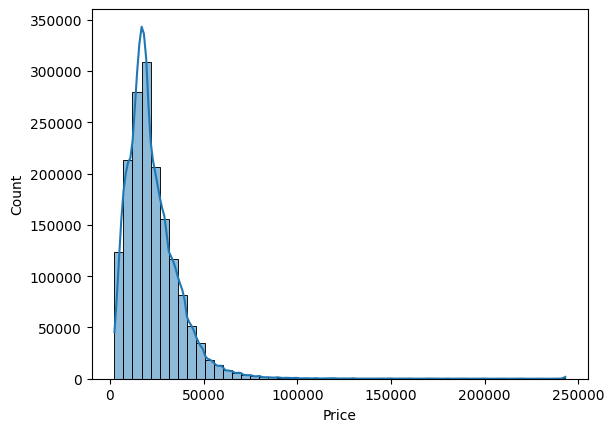

In [21]:
#Distribution of Departure Delays before handling missing values
sns.histplot(vehicles['Price'], bins=50, kde=True)

In [22]:
# A function to identify outliers using IQR
def identify_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers,lower_bound,upper_bound

In [24]:
# Identify outliers in the 'Price' column
price_outliers,price_lower_bound, price_upper_bound = identify_outliers_iqr(vehicles['Price'])
print(f"Total Number of Price outliers are observed to be {len(price_outliers)} \nwhere upper-bound and lower-bound values are {price_upper_bound},{price_lower_bound} and, \nmaximum and minimum Price values observed in the dataset are {max(vehicles['Price'])} , {min(vehicles['Price'])} respectively!!")


Total Number of Price outliers are observed to be 56213 
where upper-bound and lower-bound values are 52068.5,-9255.5 and, 
maximum and minimum Price values observed in the dataset are 242995.0 , 2495.0 respectively!!


In [25]:
# Winsorization to cap extreme values
vehicles['Price'] = mstats.winsorize(vehicles['Price'], limits=[0.005,0.0005])

# Identify outliers in the 'DEP_DELAY' column
dep_delay_outliers,dep_delay_lower_bound, dep_delay_upper_bound = identify_outliers_iqr(vehicles['Price'])
print(f"Post Winsorization, Total Number of Price outliers are observed to be {len(dep_delay_outliers)} \nwhere upper-bound and lower-bound values are {dep_delay_upper_bound},{dep_delay_lower_bound} and, \nmaximum and minimum Price values observed in the dataset are {max(vehicles['Price'])} , {min(vehicles['Price'])} respectively!!")


Post Winsorization, Total Number of Price outliers are observed to be 56213 
where upper-bound and lower-bound values are 52068.5,-9255.5 and, 
maximum and minimum Price values observed in the dataset are 242995.0 , 2495.0 respectively!!


<Axes: xlabel='Price', ylabel='Count'>

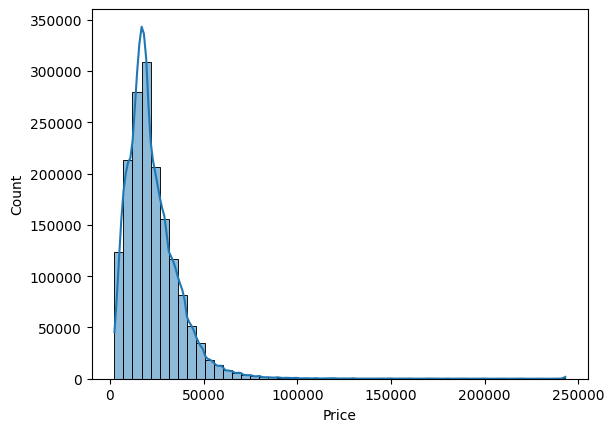

In [26]:
#Distribution of Departure Delays before handling missing values
sns.histplot(vehicles['Price'], bins=50, kde=True)

In [29]:

def most_frequent(col):
  # Filter non-null values
  filtered_col = col.dropna()
  # Return the mode (most frequent value)
  return filtered_col.mode().iloc[0] if not filtered_col.empty else None

# Group data by 'VIN' and aggregate missing values
aggregated_data = vehicles.groupby('Model Name').agg({
  'Manufacturing Year': most_frequent,  # Fill 'year' with the first non-null value
  'Manufacturer': most_frequent,        # Fill 'manufacturer' with the first non-null value
  'cylinders': most_frequent,            # Fill 'cylinders' with the most frequent value
  'drive': most_frequent,                # Fill 'drive' with the most frequent value
  'transmission': most_frequent,          # Fill 'transmission' with the most frequent value
  'State': most_frequent               # Fill 'state' with the first non-null value
})

In [30]:
aggregated_data

,Manufacturing Year,Manufacturer,cylinders,drive,transmission,State
Model Name,,,,,,
"$362.47, $1000 down, oac, 2.9%apr $362.47,luxury low miles $1000 down, only 40k miles",2018,Mercedes-Benz,4 cylinders,rwd,automatic,TX
%,2002,None,6 cylinders,fwd,automatic,AK
(300),2006,Chrysler,8 cylinders,4wd,automatic,NY
*matrix*,2004,Toyota,None,None,automatic,FL
-,2010,Mercedes-Benz,6 cylinders,4wd,automatic,KS
...,...,...,...,...,...,...
zdx,2010,Acura,6 cylinders,4wd,automatic,CO
zephyr,2006,Lincoln,6 cylinders,fwd,automatic,PA
zephyr 4dr sdn,2006,Lincoln,6 cylinders,fwd,automatic,CO


In [34]:
connection = sqlite3.connect('Scraping/UCPP_test.db')

In [35]:
cursor = connection.cursor()

table_name = 'used_cars'
query = f"SELECT * FROM {table_name}"

df = pd.read_sql_query(query, connection)

len(df)

576620

In [36]:
df.columns

Index(['index', 'Unnamed: 0', 'City', 'URL', 'Title', 'Price', 'Tags',
       'Post Content', 'Posting_Attributes', 'Manufacturing Year',
       'Manufacturer', 'Model Name', 'condition', 'cylinders', 'drive', 'fuel',
       'odometer', 'paint color', 'size', 'title status', 'transmission',
       'type', 'VIN', 'Date', 'State', 'State Name', 'City Name'],
      dtype='object')

In [37]:
vehicles.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Price', 'City', 'VIN', 'Date',
       'Manufacturing Year', 'Manufacturer', 'Model Name', 'cylinders',
       'drive', 'transmission', 'odometer', 'Post Content', 'State'],
      dtype='object')

In [38]:
df['Pre_Post_Covid'] = 'Post_Covid'
vehicles['Pre_Post_Covid'] = 'Pre_Covid'

In [40]:

# Assuming df and vehicles are already defined
# Concatenate vertically, ensuring all columns from both DataFrames are preserved
combined_df = pd.concat([df, vehicles], axis=0, ignore_index=True)

# Print or inspect the new combined DataFrame
combined_df.head()


,index,Unnamed: 0,City,URL,Title,Price,Tags,Post Content,Posting_Attributes,Manufacturing Year,...,title status,transmission,type,VIN,Date,State,State Name,City Name,Pre_Post_Covid,Unnamed: 0.1
0,0.0,0.0,abilene,https://abilene.craigslist.org/cto/d/eastland-...,1990 jeep wrangler yj,"$7,800",8h ago·145k mi·Eastland,"1990 jeep wrangler yj, 4.2 liter 6 cylinder, a...","{'Post Content': '1990 jeep wrangler yj, 4.2 l...",1990.0,...,clean,manual,None,None,2024-02-12,TX,None,"Abilene, TX",Post_Covid,NaN
1,1.0,1.0,abilene,https://abilene.craigslist.org/ctd/d/eastland-...,2015 Chevrolet Sonic LT !BUY HERE PAY HERE! Co...,None,2/12·121k mi·Eastland - Valentine's Sweet Savings,Stanley Direct Auto IN HOUSE FINANCE ONLY/NO C...,"{'Post Content': ""Stanley Direct Auto IN HOUSE...",2015.0,...,clean,automatic,sedan,None,2024-02-12,TX,None,"Abilene, TX",Post_Covid,NaN
2,2.0,2.0,abilene,https://abilene.craigslist.org/ctd/d/eastland-...,2014 Hyundai Elantra Sport !BUY HERE PAY HERE!...,None,2/12·104k mi·Eastland - Valentine's Sweet Savings,Stanley Direct Auto IN HOUSE FINANCE ONLY/NO C...,"{'Post Content': ""Stanley Direct Auto IN HOUSE...",2014.0,...,clean,automatic,sedan,None,2024-02-12,TX,None,"Abilene, TX",Post_Covid,NaN
3,3.0,3.0,abilene,https://abilene.craigslist.org/ctd/d/eastland-...,2014 Ford F-150 XLT !BUY HERE PAY HERE! Financ...,None,2/12·113k mi·Eastland - Valentine's Sweet Savings,Stanley Direct Auto IN HOUSE FINANCE ONLY/NO C...,"{'Post Content': ""Stanley Direct Auto IN HOUSE...",2014.0,...,clean,automatic,pickup,None,2024-02-12,TX,None,"Abilene, TX",Post_Covid,NaN
4,4.0,4.0,abilene,https://abilene.craigslist.org/ctd/d/eastland-...,2014 Dodge Avenger SE !BUY HERE PAY HERE! Comp...,None,2/12·112k mi·Eastland - Valentine's Sweet Savings,Stanley Direct Auto IN HOUSE FINANCE ONLY/NO C...,"{'Post Content': ""Stanley Direct Auto IN HOUSE...",2014.0,...,clean,automatic,sedan,None,2024-02-12,TX,None,"Abilene, TX",Post_Covid,NaN


In [41]:
combined_df[combined_df['Pre_Post_Covid'] == 'Pre_Covid'].head()

,index,Unnamed: 0,City,URL,Title,Price,Tags,Post Content,Posting_Attributes,Manufacturing Year,...,title status,transmission,type,VIN,Date,State,State Name,City Name,Pre_Post_Covid,Unnamed: 0.1
576620,NaN,4.0,akron / canton,NaN,NaN,242995.0,NaN,"WE HAVE MOVED TO 2517 FULTON DRIVE NW CANTON, ...",NaN,2019.0,...,NaN,automatic,NaN,00000000000000000,2021-05-04 11:31:57-04:00,OH,NaN,NaN,Pre_Covid,0.0
576621,NaN,144.0,Cleveland,NaN,NaN,159900.0,NaN,We have just added to our extensive exotic car...,NaN,2017.0,...,NaN,A,NaN,00000000020179562,NaN,OH,NaN,NaN,Pre_Covid,1.0
576622,NaN,170.0,orlando,NaN,NaN,2495.0,NaN,Truck is in Great Conditions!!! Clear Title N...,NaN,2012.0,...,NaN,manual,NaN,000000000CD152372,2021-04-29 16:33:48-04:00,FL,NaN,NaN,Pre_Covid,2.0
576623,NaN,171.0,orlando,NaN,NaN,2495.0,NaN,Truck is in Great Condition!!! Clear Title New...,NaN,2012.0,...,NaN,manual,NaN,000000000CD152374,2021-04-29 16:52:33-04:00,FL,NaN,NaN,Pre_Covid,3.0
576624,NaN,199.0,orlando,NaN,NaN,55000.0,NaN,"THIS TRUCKS RUNS, DRIVES AND LOOKS GREAT. TO...",NaN,2003.0,...,NaN,manual,NaN,0000000033D576483,2021-04-28 22:15:37-04:00,FL,NaN,NaN,Pre_Covid,4.0
